In [1]:
import numpy as np


def equation_1_hit_pixel_time(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    Implements Equation 1 (Ph_tn) from the referenced manuscript.

    For each time t and pixel n, returns the hit term as the minimum
    between x and y at that time and pixel.

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        np.ndarray, shape (T, N)
            Ph_tn for each time and pixel
    """
    ph_tn = np.minimum(x, y)
    return ph_tn


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

equation_1_results = equation_1_hit_pixel_time(
    x,
    y
)
print(
    "Equation 1 results (Ph_tn) for each time and pixel:",
    equation_1_results
)

Equation 1 results (Ph_tn) for each time and pixel: [[2 1]
 [0 4]
 [0 1]]


In [2]:
import numpy as np


def equation_2_false_alarm_pixel_time(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    Implements Equation 2 (Pf_tn) from the referenced manuscript.

    For each time t and pixel n, returns the false alarm term as
    max(0, y - x).

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        np.ndarray, shape (T, N)
            Pf_tn for each time and pixel
    """
    pf_tn = np.maximum(0, y - x)
    return pf_tn


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

equation_2_results = equation_2_false_alarm_pixel_time(
    x,
    y
)
print(
    "Equation 2 results (Pf_tn) false alarm per time and pixel:",
    equation_2_results
)


Equation 2 results (Pf_tn) false alarm per time and pixel: [[2 0]
 [1 1]
 [0 2]]


In [3]:
import numpy as np


def equation_3_miss_pixel_time(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    Implements Equation 3 (Pm_tn) from the referenced manuscript.

    For each time t and pixel n, returns the miss term as
    max(0, x - y).

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        np.ndarray, shape (T, N)
            Pm_tn for each time and pixel
    """
    pm_tn = np.maximum(0, x - y)
    return pm_tn


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

equation_3_results = equation_3_miss_pixel_time(
    x,
    y
)
print(
    "Equation 3 results (Pm_tn) miss per time and pixel:",
    equation_3_results
)


Equation 3 results (Pm_tn) miss per time and pixel: [[0 4]
 [0 0]
 [5 0]]


In [4]:
import numpy as np


def equation_4_hit_sum_time(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    Implements Equation 4 (Ph_t) from the referenced manuscript.

    For each time t, sums over pixels the hit term
    min(x_tn, y_tn).

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        np.ndarray, shape (T,)
            Ph_t for each time
    """
    ph_t = np.minimum(x, y).sum(axis=1)
    return ph_t


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

equation_4_results = equation_4_hit_sum_time(
    x,
    y
)
print(
    "Equation 4 results (Ph_t) hit sum per time:",
    equation_4_results
)


Equation 4 results (Ph_t) hit sum per time: [3 4 1]


In [5]:
import numpy as np


def equation_5_unmatched_space_time(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    Implements Equation 5 (Pu_t) from the referenced manuscript.

    For each time t:
        Pu_t = min(sum_n x_tn, sum_n y_tn) - Ph_t

    where Ph_t is Equation 4.

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        np.ndarray, shape (T,)
            Pu_t for each time
    """
    sum_x_t = x.sum(axis=1)
    sum_y_t = y.sum(axis=1)
    ph_t = equation_4_hit_sum_time(
        x,
        y
    )
    pu_t = np.minimum(sum_x_t, sum_y_t) - ph_t
    return pu_t


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

# Ensure you have the equation_4_hit_sum_time function defined as above
equation_5_results = equation_5_unmatched_space_time(
    x,
    y
)
print(
    "Equation 5 results (Pu_t) unmatched-in-space per time:",
    equation_5_results
)


Equation 5 results (Pu_t) unmatched-in-space per time: [2 0 2]


In [6]:
import numpy as np


def equation_6_false_alarm_time(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    Implements Equation 6 (Pf_t) from the referenced manuscript.

    For each time t:
        Pf_t = max(0, sum_n(y_tn - x_tn))

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        np.ndarray, shape (T,)
            Pf_t for each time
    """
    pf_t = np.maximum(0, (y - x).sum(axis=1))
    return pf_t


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

equation_6_results = equation_6_false_alarm_time(
    x,
    y
)
print(
    "Equation 6 results (Pf_t) false alarm per time:",
    equation_6_results
)


Equation 6 results (Pf_t) false alarm per time: [0 2 0]


In [7]:
import numpy as np


def equation_7_miss_time(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    Implements Equation 7 (Pm_t) from the referenced manuscript.

    For each time t:
        Pm_t = max(0, sum_n(x_tn - y_tn))

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        np.ndarray, shape (T,)
            Pm_t for each time
    """
    pm_t = np.maximum(0, (x - y).sum(axis=1))
    return pm_t


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

equation_7_results = equation_7_miss_time(
    x,
    y
)
print(
    "Equation 7 results (Pm_t) miss per time:",
    equation_7_results
)


Equation 7 results (Pm_t) miss per time: [2 0 3]


In [8]:
import numpy as np


def equation_8_global_hit_sum(
    x: np.ndarray,
    y: np.ndarray
) -> float:
    """
    Implements Equation 8 (Ph) from the referenced manuscript.

    Ph is the sum over all times and all pixels of the hit term.

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        float
            Ph global
    """
    ph_t = np.minimum(x, y).sum(axis=1)
    ph = float(ph_t.sum())
    return ph


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

equation_8_results = equation_8_global_hit_sum(
    x,
    y
)
print(
    "Equation 8 result (Ph) global hit sum:",
    equation_8_results
)


Equation 8 result (Ph) global hit sum: 8.0


In [9]:
import numpy as np


def equation_9_global_unmatched_space_sum(
    x: np.ndarray,
    y: np.ndarray
) -> float:
    """
    Implements Equation 9 (Pu) from the referenced manuscript.

    Pu is the sum over all times of Pu_t, where Pu_t is
    Equation 5.

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        float
            Pu global
    """
    pu_t = equation_5_unmatched_space_time(
        x,
        y
    )
    pu = float(pu_t.sum())
    return pu


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

# Ensure you have the equation_5_unmatched_space_time function defined as above
equation_9_results = equation_9_global_unmatched_space_sum(
    x,
    y
)
print(
    "Equation 9 result (Pu) global unmatched-in-space sum:",
    equation_9_results
)


Equation 9 result (Pu) global unmatched-in-space sum: 4.0


In [10]:
import numpy as np


def equation_10_global_time_difference(
    x: np.ndarray,
    y: np.ndarray
) -> float:
    """
    Implements Equation 10 (Pv) from the referenced manuscript.

    Pv measures disagreement in time after accounting for
    spatial match.

    Pv = min(total_x, total_y) - (Ph + Pu)

    where:
        total_x = sum over all times and pixels of x
        total_y = sum over all times and pixels of y
        Ph is Equation 8
        Pu is Equation 9

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        float
            Pv global
    """
    total_x = float(x.sum())
    total_y = float(y.sum())
    ph = equation_8_global_hit_sum(
        x,
        y
    )
    pu = equation_9_global_unmatched_space_sum(
        x,
        y
    )
    pv = min(total_x, total_y) - (ph + pu)
    return pv


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

# Ensure you have equation_8_global_hit_sum and
# equation_9_global_unmatched_space_sum defined as above
equation_10_results = equation_10_global_time_difference(
    x,
    y
)
print(
    "Equation 10 result (Pv) global time difference:",
    equation_10_results
)


Equation 10 result (Pv) global time difference: 2.0


In [11]:
import numpy as np


def equation_11_global_false_alarm_sum(
    x: np.ndarray,
    y: np.ndarray
) -> float:
    """
    Implements Equation 11 (Pf) from the referenced manuscript.

    Pf is the global false alarm term:
        Pf = max(0, sum_{t,n}(y_tn - x_tn))

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        float
            Pf global
    """
    pf = float(np.maximum(0, (y - x).sum()))
    return pf


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

equation_11_results = equation_11_global_false_alarm_sum(
    x,
    y
)
print(
    "Equation 11 result (Pf) global false alarm sum:",
    equation_11_results
)


Equation 11 result (Pf) global false alarm sum: 0.0


In [12]:
import numpy as np


def equation_12_global_miss_sum(
    x: np.ndarray,
    y: np.ndarray
) -> float:
    """
    Implements Equation 12 (Pm) from the referenced manuscript.

    Pm is the global miss term:
        Pm = max(0, sum_{t,n}(x_tn - y_tn))

    Args:
        x: np.ndarray, shape (T, N)
            first time series, values for each pixel and time
        y: np.ndarray, shape (T, N)
            second time series, values for each pixel and time
    Returns:
        float
            Pm global
    """
    pm = float(np.maximum(0, (x - y).sum()))
    return pm


# Example usage with your data
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

equation_12_results = equation_12_global_miss_sum(
    x,
    y
)
print(
    "Equation 12 result (Pm) global miss sum:",
    equation_12_results
)


Equation 12 result (Pm) global miss sum: 3.0


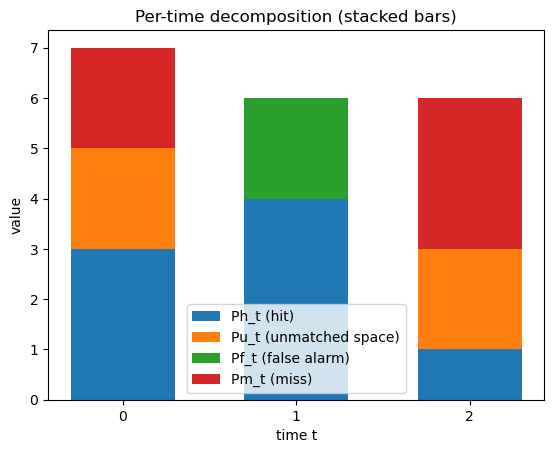

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# helper functions following equations 4–7

def equation_4_hit_sum_time(
    x: np.ndarray,
    y: np.ndarray,
) -> np.ndarray:
    """
    Ph_t = sum over pixels n of min(x_tn, y_tn)
    Returns one value per time t.
    """
    return np.minimum(x, y).sum(axis=1)


def equation_5_unmatched_space_time(
    x: np.ndarray,
    y: np.ndarray,
) -> np.ndarray:
    """
    Pu_t = min(sum_n x_tn, sum_n y_tn) - Ph_t
    Captures quantity present in the same time t but not in the same pixel.
    """
    sum_x_t = x.sum(axis=1)
    sum_y_t = y.sum(axis=1)
    ph_t = equation_4_hit_sum_time(
        x,
        y,
    )
    return np.minimum(sum_x_t, sum_y_t) - ph_t


def equation_6_false_alarm_time(
    x: np.ndarray,
    y: np.ndarray,
) -> np.ndarray:
    """
    Pf_t = max(0, sum_n(y_tn - x_tn))
    Quantity that appears in y but not in x at time t.
    """
    return np.maximum(0, (y - x).sum(axis=1))


def equation_7_miss_time(
    x: np.ndarray,
    y: np.ndarray,
) -> np.ndarray:
    """
    Pm_t = max(0, sum_n(x_tn - y_tn))
    Quantity that appears in x but not in y at time t.
    """
    return np.maximum(0, (x - y).sum(axis=1))


# input data
# rows = time steps t
# columns = pixels n
x = np.array(
    [
        [2, 5],
        [0, 4],
        [5, 1],
    ]
)
y = np.array(
    [
        [4, 1],
        [1, 5],
        [0, 3],
    ]
)

# compute per-time components
ph_t = equation_4_hit_sum_time(
    x,
    y,
)  # agreement in same pixel at same time
pu_t = equation_5_unmatched_space_time(
    x,
    y,
)  # agreement in same time but different pixel
pf_t = equation_6_false_alarm_time(
    x,
    y,
)  # extra in y
pm_t = equation_7_miss_time(
    x,
    y,
)  # extra in x

# x-axis will be the time indices t = 0,1,2
t_vals = np.arange(x.shape[0])
bar_width = 0.6

# to stack bars, define the vertical offsets ("bottom") for each layer
bottom_pu = ph_t
bottom_pf = ph_t + pu_t
bottom_pm = ph_t + pu_t + pf_t

# plot stacked bars
plt.figure()

plt.bar(
    t_vals,
    ph_t,
    bar_width,
    label="Ph_t (hit)",
)
plt.bar(
    t_vals,
    pu_t,
    bar_width,
    bottom=bottom_pu,
    label="Pu_t (unmatched space)",
)
plt.bar(
    t_vals,
    pf_t,
    bar_width,
    bottom=bottom_pf,
    label="Pf_t (false alarm)",
)
plt.bar(
    t_vals,
    pm_t,
    bar_width,
    bottom=bottom_pm,
    label="Pm_t (miss)",
)

# axis labels and legend
plt.xticks(
    t_vals,
    t_vals,
)
plt.xlabel("time t")
plt.ylabel("value")
plt.title("Per-time decomposition (stacked bars)")
plt.legend()

plt.show()
